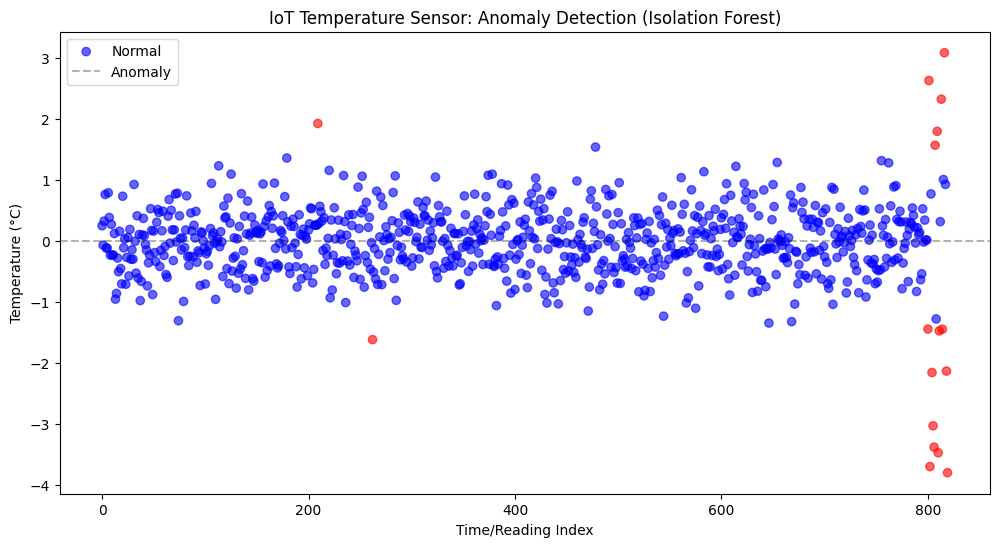

Total anomalies detected: 17


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Generate Synthetic IoT Sensor Data
np.random.seed(42)

# Normal operating conditions (800 readings)
normal_data = np.random.normal(0, 0.5, (800, 1))

# Anomalies (20 readings: some high spikes, some low drops)
outliers = np.random.uniform(low=-4, high=4, size=(20, 1))

# Combine into one dataset
data = np.concatenate([normal_data, outliers], axis=0)
df = pd.DataFrame(data, columns=['Temperature'])

# 2. Initialize and Train Isolation Forest
# contamination: the expected proportion of outliers in the data
model = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
model.fit(df[['Temperature']])

# 3. Predict Anomalies
# -1 indicates an anomaly, 1 indicates normal data
df['Anomaly_Score'] = model.decision_function(df[['Temperature']])
df['Is_Anomaly'] = model.predict(df[['Temperature']])

# 4. Visualize the Results
plt.figure(figsize=(12, 6))
colors = {1: 'blue', -1: 'red'}

plt.scatter(df.index, df['Temperature'],
            c=df['Is_Anomaly'].map(colors),
            label='Data Points', alpha=0.6)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title('IoT Temperature Sensor: Anomaly Detection (Isolation Forest)')
plt.xlabel('Time/Reading Index')
plt.ylabel('Temperature (°C)')
plt.legend(['Normal', 'Anomaly'])
plt.show()

# Display the detected anomalies
print(f"Total anomalies detected: {len(df[df['Is_Anomaly'] == -1])}")